# K Nearest Neighbours Modelini Kullanarak Diyabet Tespiti

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

#outcome = 1 is diabetes
#outcome = 0 is healthy
#kaggle'dan verilerimizi alıyoruz, önce indirip python dosyamızla aynı dizine ekliyoruz.
data = pd.read_csv("diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
saglikli = data[data.Outcome == 0]
hasta = data[data.Outcome == 1]

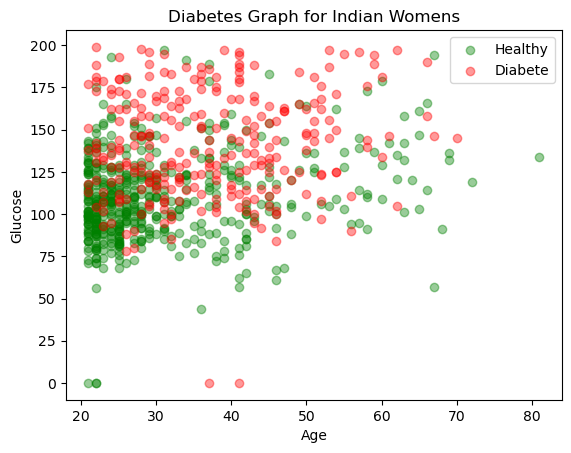

In [8]:
plt.title("Diabetes Graph for Indian Womens")
plt.scatter(saglikli.Age, saglikli.Glucose, color="green", label="Healthy",alpha = 0.4)
plt.scatter(hasta.Age, hasta.Glucose, color="red", label="Diabete",alpha = 0.4)
plt.xlabel("Age")
plt.ylabel("Glucose")
plt.legend()
plt.show()

In [66]:
y = data.Outcome.values #y değeri belirleme
x_ham_veri =data.drop(["Outcome"],axis=1) #x değeri belirleme ilk adım
#outcome sütununu çıkarıyoruz sadece independent değişkenleri tutuyoruz
#çünkü KNN algoritması x değerleri içinde gruplandırma yapacak

#normalization yapıyoruz -> x_ham_veri içindeki değerleri sadece 0 ile 1 arasında olacak şekilde güncelliyoruz
#çünkü bu şekilde normalizasyon yapmazsak verideki yüksek sayılar küçük sayıları ezer ve KNN algoritmasını yanıltabilir
x = (x_ham_veri - np.min(x_ham_veri))/(np.max(x_ham_veri) - np.min(x_ham_veri))

#önce
print("Normalizasyon öncesi ham veriler:\n")
print(x_ham_veri.head())

#sonra
print("Normalizasyon sonrası modeli eğitmek için kullanılacak veriler:\n")
print(x.head())

Normalizasyon öncesi ham veriler:

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  
Normalizasyon sonrası modeli eğitmek için kullanılacak veriler:

   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.007092  0.174941       0.085106       0.041371  0.000000  0.039716   
1     0.001182  0.100473       0.078014       0.034279  0.000000  0.031442   
2     0.009456  0.21631

In [76]:
#train data ile test datayı ayırıyoruz
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.1,random_state=1)

#knn modelini oluşturuyoruz
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)
prediction= knn.predict(x_test)
print("k=3 için test verilerimizin doğrulama testi sonucu : ",knn.score(x_test,y_test))


k=3 için test verilerimizin doğrulama testi sonucu :  0.7792207792207793


In [78]:
#k kaç olmalı?
# en iyi k değerini bulma
sayac=1
for k in range(1,11):
    knn_yeni= KNeighborsClassifier(n_neighbors=k)
    knn_yeni.fit(x_train,y_train)
    print(sayac," ","Doğruluk oranı: %",knn_yeni.score(x_test,y_test))
    sayac +=1

1   Doğruluk oranı: % 0.7922077922077922
2   Doğruluk oranı: % 0.7402597402597403
3   Doğruluk oranı: % 0.7792207792207793
4   Doğruluk oranı: % 0.7402597402597403
5   Doğruluk oranı: % 0.7272727272727273
6   Doğruluk oranı: % 0.7532467532467533
7   Doğruluk oranı: % 0.7402597402597403
8   Doğruluk oranı: % 0.7662337662337663
9   Doğruluk oranı: % 0.7662337662337663
10   Doğruluk oranı: % 0.7662337662337663


# Veri seti İçinde Olmayan Yeni bir Hastanın Tahlil Sonuçlarına Göre Prediction

In [86]:
#yeni hasta tahmini için
from sklearn.preprocessing import MinMaxScaler

#normalizasyon yapıyoruz -daha hızlı normalizasyon yapabilmek için MinMax scaler kullanıyoruz
sc = MinMaxScaler()
sc.fit_transform(x_ham_veri)

new_prediction = knn.predict(sc.transform(np.array([[6,148,72,35,0,33.6,0.627,50]])))
new_prediction[0]

0